---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Aula Um: O que é Machine Learning?</h1>

<h3 align="center">PhD. in progress Samir Ramos</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

# Projeto 1: Crescimento de um App de Corridas e Capacidade de Servidores (AWS)

**Objetivo da parte 1 da aula:**

- Relembrar o que é **regressão linear** na prática.
- Trabalhar passo a passo o código Python (linha a linha).
- Medir a qualidade do modelo com **R², MAE, MSE, RMSE**.
- Usar o modelo para prever **quando** precisamos escalar servidores (AWS Auto Scaling).

1.3. Setup e leitura dos dados

In [ ]:
import numpy as np          # biblioteca para cálculos numéricos (vetores, matrizes)
import pandas as pd         # biblioteca para trabalhar com tabelas (DataFrame)
import matplotlib.pyplot as plt  # biblioteca para gráficos
import matplotlib.dates as mdates  # ajuda a formatar datas nos gráficos
from datetime import timedelta     # para somar dias em datas
from pathlib import Path           # para trabalhar com caminhos de arquivos

======>>>>> VEJA O SLIDE DO PROFESSOR PARA EXPLICAÇÃO DETALHADA


In [ ]:
# caminho do arquivo de dados (já gerado antes)
PATH_CSV = Path("data/rides_app.csv")

# ler o arquivo CSV em um DataFrame
df = pd.read_csv(PATH_CSV)

# mostrar as 5 primeiras linhas da tabela
df.head()

======>>>>> VEJA O SLIDE DO PROFESSOR PARA EXPLICAÇÃO DETALHADA

---
## 1. Ler dados

Conectamos ao banco, lemos **timestamp** e **heat_efficiency**. Os timestamps reais da base são usados na tabela e nos gráficos; internamente o modelo usa tempo em dias a partir da primeira data como variável de entrada.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

PATH_CSV = Path("data/heat_exchanger.csv")
df_full = pd.read_csv(PATH_CSV)

# Garante ordem temporal para análises e regressão
df_full = df_full.sort_values("timestamp").reset_index(drop=True)

# Timestamps reais da base (para exibição em gráficos e resultados)
datas = pd.to_datetime(df_full["timestamp"], format="%Y-%m-%d").tolist()
dia_zero = datas[0]
# Tempo em dias (número) apenas para o modelo de regressão
tempo_dias = np.array([(d - dia_zero).days for d in datas], dtype=np.float64)
eficiencia = df_full["heat_efficiency"].to_numpy(dtype=np.float64)

# Variáveis de temperatura
water_in = df_full["water_inlet_temperature"].to_numpy()
glycol_in = df_full["glycol_inlet_temperature"].to_numpy()
glycol_out = df_full["out_glycol_temperature"].to_numpy()
water_out = df_full["out_water_temperature"].to_numpy()
eficiencia_termica = eficiencia  # mesma série

# Formato para regressão: X = tempo (coluna única), y = eficiência
X = tempo_dias.reshape(-1, 1)  # shape (n_amostras, 1)
y = eficiencia

# Tabela fluida com timestamp real e eficiência (amostra)
df = df_full[["timestamp", "heat_efficiency"]].copy()
df.head()

,timestamp,heat_efficiency
0,2022-01-01,96.454517
1,2022-01-02,96.432576
2,2022-01-03,96.410674
3,2022-01-04,96.388810
4,2022-01-05,96.366986


---
## 2. Apresentar os dados (gráficos)

O trocador de calor possui quatro variáveis de temperatura (**entrada** e **saída** de água e de glicol) e a **eficiência térmica**. Abaixo, plotamos separadamente: água, glicol e eficiência em função do **timestamp** (data real da base).

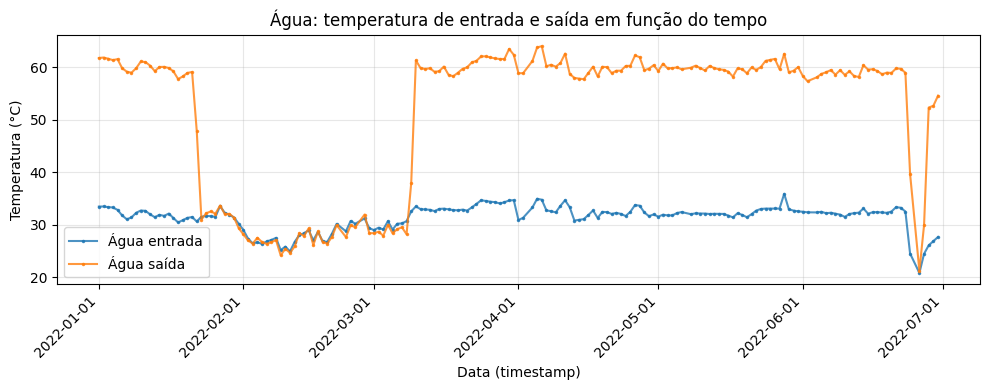

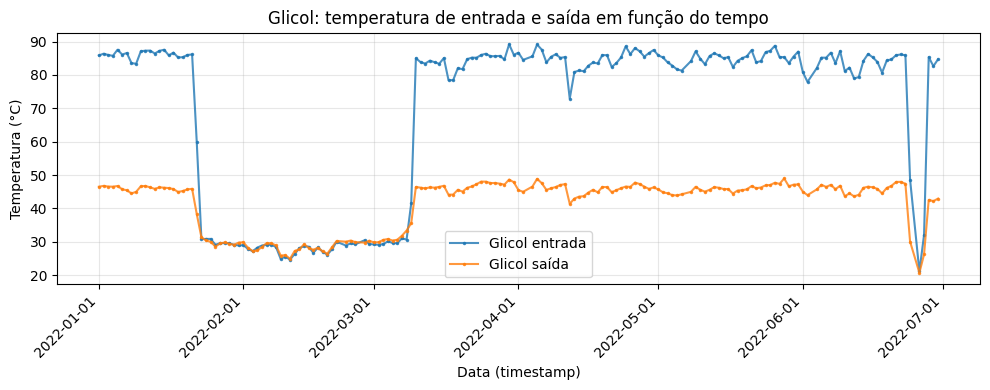

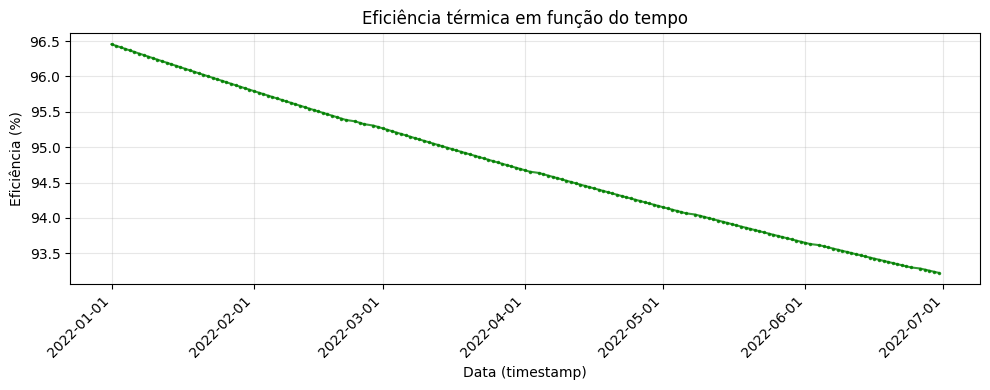

In [ ]:
# Reutiliza dados carregados na seção 1 (datas, water_in, glycol_in, etc.)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Gráfico 1: Água (entrada e saída)
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(datas, water_in, ".-", label="Água entrada", alpha=0.8, markersize=3)
ax1.plot(datas, water_out, ".-", label="Água saída", alpha=0.8, markersize=3)
ax1.set_xlabel("Data (timestamp)")
ax1.set_ylabel("Temperatura (°C)")
ax1.set_title("Água: temperatura de entrada e saída em função do tempo")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Glicol (entrada e saída)
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(datas, glycol_in, ".-", label="Glicol entrada", alpha=0.8, markersize=3)
ax2.plot(datas, glycol_out, ".-", label="Glicol saída", alpha=0.8, markersize=3)
ax2.set_xlabel("Data (timestamp)")
ax2.set_ylabel("Temperatura (°C)")
ax2.set_title("Glicol: temperatura de entrada e saída em função do tempo")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 3: Eficiência térmica
fig3, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(datas, eficiencia_termica, ".-", color="green", alpha=0.8, markersize=3)
ax3.set_xlabel("Data (timestamp)")
ax3.set_ylabel("Eficiência (%)")
ax3.set_title("Eficiência térmica em função do tempo")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax3.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Apresentar o modelo de regressão linear

O modelo de regressão linear simples é:

$$y = \beta_0 + \beta_1 \cdot t$$

onde $t$ é o tempo (dias) e $y$ é a eficiência. Os parâmetros $\beta_0$ (intercepto) e $\beta_1$ (coeficiente angular) definem a reta que buscamos ajustar aos dados.

---
## 4. Abordagem para ajustar parâmetros (maximizando R²)

Queremos escolher $\beta_0$ e $\beta_1$ de modo que o modelo se ajuste bem aos dados. Isso equivale a **minimizar a soma dos quadrados dos resíduos** (SSE):

$$\text{SSE} = \sum_i (y_i - \hat{y}_i)^2$$

Minimizar o SSE é equivalente a **maximizar o R²** (coeficiente de determinação). Para a regressão linear, existe **solução em forma fechada** pela **equação normal**:

$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

com $\mathbf{X}$ incluindo uma coluna de 1s para o termo constante (intercepto).

In [ ]:
# Montar matriz X com coluna de 1s (intercepto)
n = len(y)
X_b = np.hstack([np.ones((n, 1)), X])  # shape (n, 2)

# Equação normal: beta = (X' X)^(-1) X' y
beta = np.linalg.solve(X_b.T @ X_b, X_b.T @ y)
beta0, beta1 = beta[0], beta[1]

# Predições
y_pred = X_b @ beta # equivalente a y_pred = np.dot(X_b, beta)

print("Parâmetros do modelo (regressão linear simples):")
print("  Intercepto (beta0): {:.4f}".format(beta0))
print("  Coeficiente do tempo (beta1): {:.6f}".format(beta1))
print("  Equação: eficiência = {:.4f} + {:.6f} * tempo_dias".format(beta0, beta1))

Parâmetros do modelo (regressão linear simples):
  Intercepto (beta0): 96.3428
  Coeficiente do tempo (beta1): -0.017919
  Equação: eficiência = 96.3428 + -0.017919 * tempo_dias


---
## 5. Apresentar resultados

### 5.1 Métricas

O **R² (coeficiente de determinação)** mede quanto da variação de $y$ é explicada pelo modelo:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

Valores próximos de 1 indicam bom ajuste; próximos de 0 indicam que o modelo não explica bem a variabilidade dos dados.

In [ ]:
ss_res = np.sum((y - y_pred) ** 2)   # soma dos quadrados dos resíduos
ss_tot = np.sum((y - y.mean()) ** 2) # soma total dos quadrados
r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

print("R² (coeficiente de determinação): {:.4f}".format(r2))
print("Interpretação: {:.2f}% da variação da eficiência é explicada pelo tempo.".format(r2 * 100))

R² (coeficiente de determinação): 0.9975
Interpretação: 99.75% da variação da eficiência é explicada pelo tempo.


### 5.2 Gráficos

Pontos = dados reais; reta = predição do modelo de regressão linear.

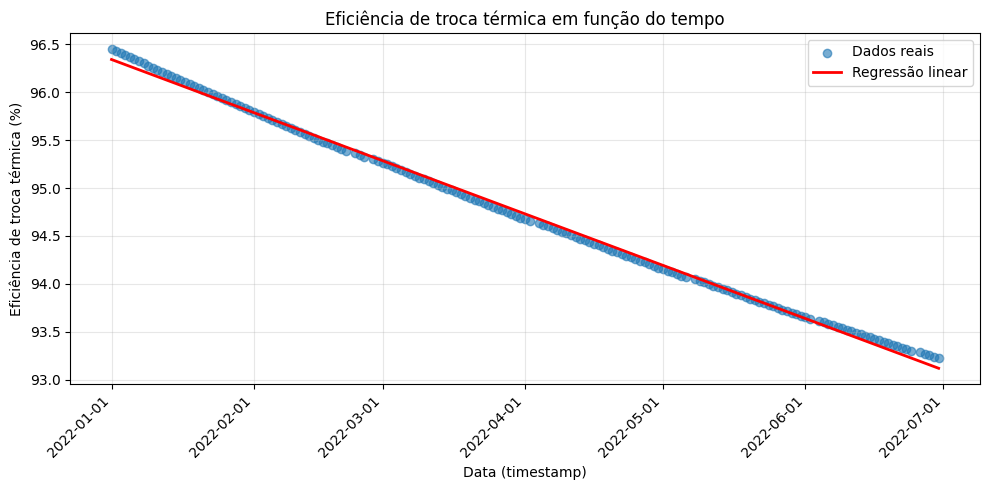

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(datas, y, alpha=0.6, label="Dados reais")
ax.plot(datas, y_pred, color="red", linewidth=2, label="Regressão linear")
ax.set_xlabel("Data (timestamp)")
ax.set_ylabel("Eficiência de troca térmica (%)")
ax.set_title("Eficiência de troca térmica em função do tempo")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Previsão: quando limpar o trocador de calor?

Com o modelo ajustado, podemos estimar **em qual data (timestamp) a eficiência atingirá 92%**. Abaixo desse patamar, considera-se necessário realizar a **limpeza do trocador de calor** para recuperar a performance.

Da equação do modelo $y = \beta_0 + \beta_1 \cdot t$, obtemos o tempo em dias para uma eficiência alvo $y_{\text{alvo}}$; em seguida convertemos para a **data real** correspondente na base.

$$t = \frac{y_{\text{alvo}} - \beta_0}{\beta_1}$$

In [ ]:
# Eficiência alvo: data em que será necessário limpar o trocador
eficiencia_alvo = 92.0
from datetime import timedelta
# t (dias) = (y_alvo - beta0) / beta1
dia_limpeza = (eficiencia_alvo - beta0) / beta1
data_limpeza = dia_zero + timedelta(days=dia_limpeza)

print("Previsão com base no modelo de regressão linear:")
print("  Eficiência alvo: {:.1f}%".format(eficiencia_alvo))
print("  Data (timestamp) em que a eficiência atinge {:.0f}%: {}".format(eficiencia_alvo, data_limpeza.strftime("%Y-%m-%d")))
print()
if dia_limpeza > 0:
    print("  → Recomendação: planejar a limpeza do trocador de calor por volta de {}.".format(data_limpeza.strftime("%Y-%m-%d")))
else:
    print("  → O modelo indica que o ponto de 92% já foi ultrapassado. Avalie a limpeza em breve.")

Previsão com base no modelo de regressão linear:
  Eficiência alvo: 92.0%
  Data (timestamp) em que a eficiência atinge 92%: 2022-08-31

  → Recomendação: planejar a limpeza do trocador de calor por volta de 2022-08-31.


---
## 8. Interpretação dos parâmetros e relação com ML mais complexo

### O que temos neste modelo
- **$\beta_0$ (intercepto):** valor esperado da eficiência quando o tempo é zero (início da série).
- **$\beta_1$ (coeficiente do tempo):** variação média da eficiência por dia. Se $\beta_1 < 0$, a eficiência tende a diminuir com o tempo (ex.: degradação); se $\beta_1 > 0$, tende a aumentar.

### Ligação com modelos de ML mais complexos
1. **Mesma ideia central:** encontrar **parâmetros** que minimizem o erro entre predição e valor real. Na regressão linear usamos a solução analítica; em redes neurais e outros modelos usamos **otimização iterativa** (ex.: gradiente descendente).
2. **Mais variáveis:** em vez de só tempo, podemos usar várias features (temperaturas, vazões, etc.) → **regressão linear múltipla** ou **modelos lineares generalizados**.
3. **Relações não lineares:** quando uma reta não descreve bem os dados, entram **polinômios**, **árvores de decisão**, **redes neurais** etc., que aprendem funções não lineares a partir dos dados.
4. **Treino e avaliação:** aqui ajustamos em todos os pontos; em ML é comum separar **treino** e **teste** para avaliar generalização, assim como em modelos mais complexos.

Assim, a regressão linear simples é a **base conceitual**: entrada → modelo (parâmetros) → saída predita; o que muda nos modelos complexos é a **forma do modelo** e o **método de aprendizado** dos parâmetros.